<img src = "boy.png" style = "width : 200px; height : 200px;" />

In [60]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

Reading the Dataset with Pandas

In [5]:
df = pd.read_csv('credit_card_fraud_10k.csv')
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


### EDA

In [6]:
df.shape

(10000, 10)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,5000.500000,2886.895680,1.0,2500.750,5000.500,7500.25,10000.00
amount,10000.0,175.949849,175.392827,0.0,50.905,122.095,242.48,1471.04
transaction_hour,10000.0,11.593300,6.922708,0.0,6.000,12.000,18.00,23.00
foreign_transaction,10000.0,0.097800,0.297059,0.0,0.000,0.000,0.00,1.00
location_mismatch,10000.0,0.085700,0.279935,0.0,0.000,0.000,0.00,1.00
device_trust_score,10000.0,61.798900,21.487053,25.0,43.000,62.000,80.00,99.00
velocity_last_24h,10000.0,2.008900,1.432559,0.0,1.000,2.000,3.00,9.00
cardholder_age,10000.0,43.468700,14.979147,18.0,30.000,44.000,56.00,69.00
is_fraud,10000.0,0.015100,0.121957,0.0,0.000,0.000,0.00,1.00


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
numerical_df = df.select_dtypes(include = 'number')

In [12]:
numerical_df

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,0,0,66,3,40,0
1,2,541.82,3,1,0,87,1,64,0
2,3,237.01,17,0,0,49,1,61,0
3,4,164.33,4,0,1,72,3,34,0
4,5,30.53,15,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,0,0,99,4,37,0
9996,9997,410.04,5,0,0,70,3,25,0
9997,9998,527.75,21,0,0,44,2,45,0
9998,9999,91.20,2,0,0,38,0,37,0


In [13]:
numerical_df.corr()['is_fraud']

transaction_id        -0.010155
amount                 0.028404
transaction_hour      -0.138665
foreign_transaction    0.185597
location_mismatch      0.173009
device_trust_score    -0.137913
velocity_last_24h      0.103413
cardholder_age        -0.000590
is_fraud               1.000000
Name: is_fraud, dtype: float64

<Axes: >

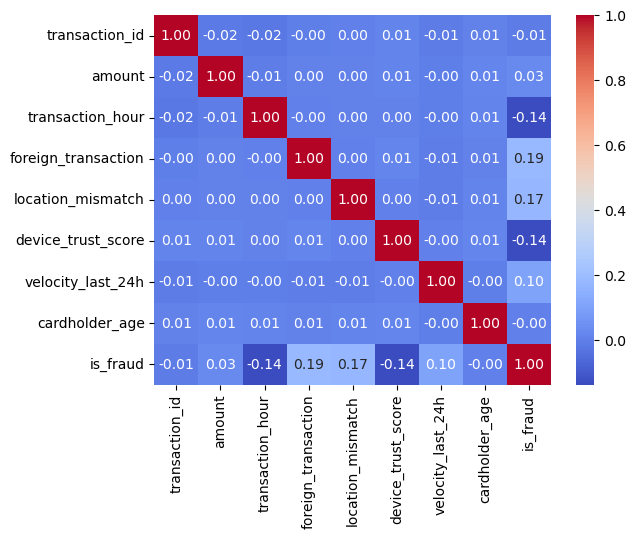

In [14]:
sns.heatmap(numerical_df.corr(), annot = True, fmt = '.2f', cmap = "coolwarm")

In [15]:
numerical_df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'cardholder_age', 'is_fraud'],
      dtype='object')

In [16]:
numerical_col = ['transaction_id', 'amount', 'transaction_hour', 'foreign_transaction',
                 'location_mismatch', 'device_trust_score', 'velocity_last_24h','cardholder_age']

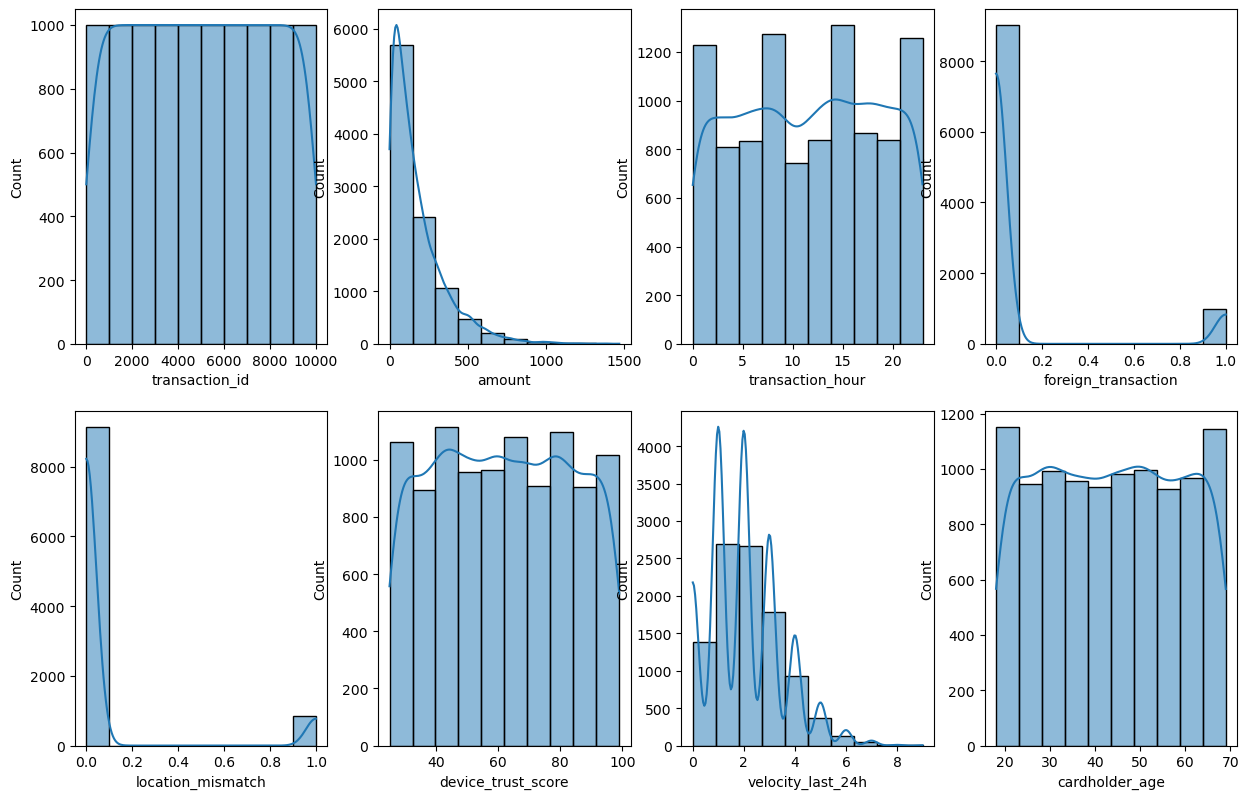

In [17]:
plt.figure(figsize = (15, 20))

for i, col in enumerate(numerical_col):
    plt.subplot(4, 4, i + 1)
    sns.histplot(numerical_df[col], kde = True, bins = 10)
plt.show()

<Axes: xlabel='merchant_category'>

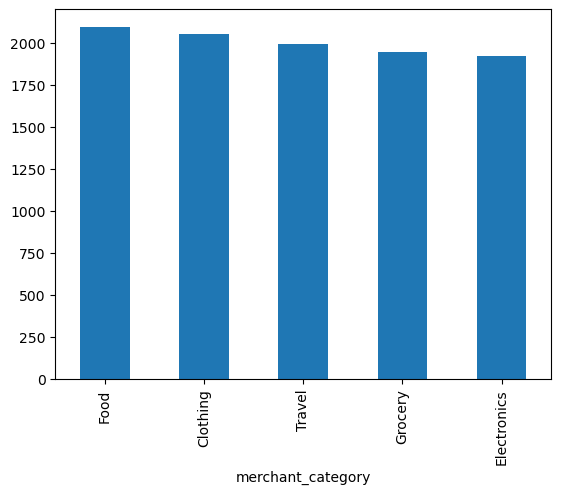

In [18]:
df.merchant_category.value_counts().plot(kind = 'bar')

<Axes: xlabel='is_fraud'>

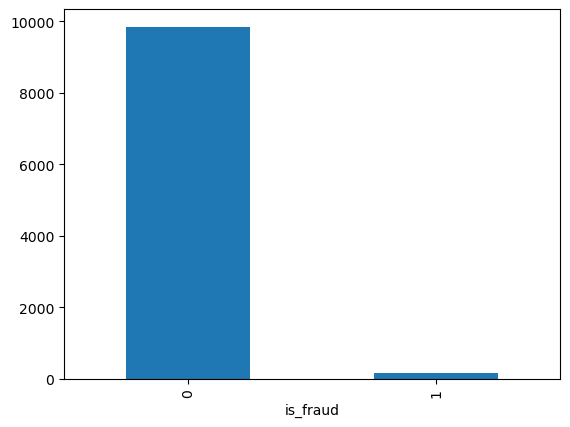

In [19]:
df.is_fraud.value_counts().plot(kind = 'bar')

In [20]:
df.is_fraud.value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

### Standardizing and spliting the Dataset

In [21]:
X = numerical_df.drop(columns = ['is_fraud', 'transaction_id'])
y = numerical_df['is_fraud']

# Scaling the X_features
scale = StandardScaler()
X_scaled = scale.fit_transform(X)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, random_state = 42)

In [23]:
def create_model(classifier):
    model = classifier(class_weight = 'balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = print(classification_report(y_test, y_pred))

    return score


In [24]:
create_model(DecisionTreeClassifier)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2946
           1       0.94      0.81      0.87        54

    accuracy                           1.00      3000
   macro avg       0.97      0.91      0.93      3000
weighted avg       1.00      1.00      1.00      3000



In [25]:
create_model(RandomForestClassifier)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2946
           1       1.00      0.50      0.67        54

    accuracy                           0.99      3000
   macro avg       1.00      0.75      0.83      3000
weighted avg       0.99      0.99      0.99      3000



In [26]:
create_model(LogisticRegression)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      2946
           1       0.29      0.94      0.45        54

    accuracy                           0.96      3000
   macro avg       0.65      0.95      0.71      3000
weighted avg       0.99      0.96      0.97      3000



In [27]:
X = df.drop(columns = ['is_fraud', 'transaction_id', 'merchant_category'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [28]:
X

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
0,84.47,22,0,0,66,3,40
1,541.82,3,1,0,87,1,64
2,237.01,17,0,0,49,1,61
3,164.33,4,0,1,72,3,34
4,30.53,15,0,0,79,0,44
...,...,...,...,...,...,...,...
9995,350.91,22,0,0,99,4,37
9996,410.04,5,0,0,70,3,25
9997,527.75,21,0,0,44,2,45
9998,91.20,2,0,0,38,0,37


In [29]:
pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('DTC', DecisionTreeClassifier(class_weight = 'balanced', random_state = 42))
]
)

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('DTC', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [30]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2946
           1       0.98      0.81      0.89        54

    accuracy                           1.00      3000
   macro avg       0.99      0.91      0.94      3000
weighted avg       1.00      1.00      1.00      3000



In [96]:
joblib.dump(pipeline, 'prediction.joblib')

['prediction.joblib']

In [31]:
mod = joblib.load('prediction.joblib')

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.1 when using version 1.7.2. This might lead to breaking 

In [32]:
mod.predict(X_test).shape

(3000,)

In [33]:
y_pred.shape

(3000,)

In [107]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [70]:
y_prob = mod.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_prob[:, 1])
auc = roc_auc_score(y_test, y_prob[:, 1])

print(f'threshold: {threshold[1]}')
print(f'auc: {auc}')

threshold: 1.0
auc: 0.9072376857509241


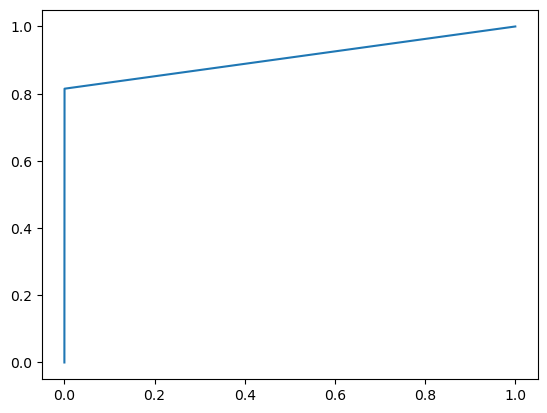

In [ ]:
plt.plot(fpr, tpr)

plt.show()

In [71]:
import numpy as np

# fpr, tpr, thresholds came from roc_curve
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = threshold[best_idx]

print(f"Best Threshold: {best_threshold:.3f}")

Best Threshold: 1.000


In [72]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# 1. Get probabilities for class 1
y_prob = mod.predict_proba(X_test)[:, 1]  

# 2. Get ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)  

# 3. Find best threshold
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"AUC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"At best threshold -> TPR: {tpr[best_idx]:.3f}, FPR: {fpr[best_idx]:.3f}")

AUC: 0.907
Best Threshold: 1.000
At best threshold -> TPR: 0.815, FPR: 0.000
